<a href="https://colab.research.google.com/github/law850/data-analytics-portfolio/blob/main/SQL_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd

df = pd.read_csv("students_subject_marks.csv")
print("-----------The list of columns in the dataset---------")
print(df.columns.tolist())
print("------The first 5 rows---------")
df.head()

-----------The list of columns in the dataset---------
['Student_ID', 'Student_Name', 'Mathematics', 'English', 'Biology', 'Chemistry', 'Physics', 'Computer_Studies']
------The first 5 rows---------


,Student_ID,Student_Name,Mathematics,English,Biology,Chemistry,Physics,Computer_Studies
0,STU0001,Oscar Otieno,80,93,28,86,39,81
1,STU0002,Queen Onyango,53,2,6,72,90,96
2,STU0003,Irene Wambui,96,74,55,3,5,63
3,STU0004,Caroline Maina,78,68,44,9,48,86
4,STU0005,Kevin Chebet,100,51,5,31,0,64


loading the dataset and display the first 5 rows

In [24]:
print("--- Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


print("\n--- Data Types ---")
print(df.dtypes)


--- Shape ---
Rows: 2000, Columns: 8

--- Data Types ---
Student_ID          object
Student_Name        object
Mathematics          int64
English              int64
Biology              int64
Chemistry            int64
Physics              int64
Computer_Studies     int64
dtype: object


to check  on the number of rows and column and the datatypes of the rows

In [25]:
# Check for missing values
print("--- Missing Values per Column ---")
print(df.isnull().sum())

print("\n--- Percentage Missing ---")
print((df.isnull().sum() / len(df)) * 100)

# Check for duplicates
print(f"\n--- Duplicate Rows: {df.duplicated().sum()} ---")

--- Missing Values per Column ---
Student_ID          0
Student_Name        0
Mathematics         0
English             0
Biology             0
Chemistry           0
Physics             0
Computer_Studies    0
dtype: int64

--- Percentage Missing ---
Student_ID          0.0
Student_Name        0.0
Mathematics         0.0
English             0.0
Biology             0.0
Chemistry           0.0
Physics             0.0
Computer_Studies    0.0
dtype: float64

--- Duplicate Rows: 0 ---


data cleaning,,, for checking the missing values as well the duplicates in the datatype and there correspondence percentage

In [26]:
# Define the subject columns (exclude ID and Name)
subject_cols = ['Mathematics', 'English', 'Biology', 'Chemistry', 'Physics', 'Computer_Studies']

# Check the minimum and maximum score for each subject
print("--- Score Ranges per Subject ---")
for subject in subject_cols:
    min_score = df[subject].min()
    max_score = df[subject].max()
    print(f"{subject}: min = {min_score}, max = {max_score}")

--- Score Ranges per Subject ---
Mathematics: min = 0, max = 100
English: min = 0, max = 100
Biology: min = 0, max = 100
Chemistry: min = 0, max = 100
Physics: min = 0, max = 100
Computer_Studies: min = 0, max = 100


validation of score ranges and check for outliers

In [27]:
# Add a Total and Average column
df['Total'] = df[subject_cols].sum(axis=1)
df['Average'] = df[subject_cols].mean(axis=1).round(2)

# Show the updated DataFrame
df.head()

,Student_ID,Student_Name,Mathematics,English,Biology,Chemistry,Physics,Computer_Studies,Total,Average
0,STU0001,Oscar Otieno,80,93,28,86,39,81,407,67.83
1,STU0002,Queen Onyango,53,2,6,72,90,96,319,53.17
2,STU0003,Irene Wambui,96,74,55,3,5,63,296,49.33
3,STU0004,Caroline Maina,78,68,44,9,48,86,333,55.50
4,STU0005,Kevin Chebet,100,51,5,31,0,64,251,41.83


adding Average and Total column and display the first 5 rows

In [31]:
# Summary statistics for all subjects
print("--- Descriptive Statistics ---")

# Most and least performing students
top_student = df.loc[df['Average'].idxmax()]
bottom_student = df.loc[df['Average'].idxmin()]

print(f"\n🏆 Top Performer: {top_student['Student_Name']} (Average: {top_student['Average']})")
print(f"📉 Lowest Performer: {bottom_student['Student_Name']} (Average: {bottom_student['Average']})")

--- Descriptive Statistics ---

🏆 Top Performer: Kevin Kariuki (Average: 88.17)
📉 Lowest Performer: Mercy Mutua (Average: 6.17)


To show the top student and bottom student and there average

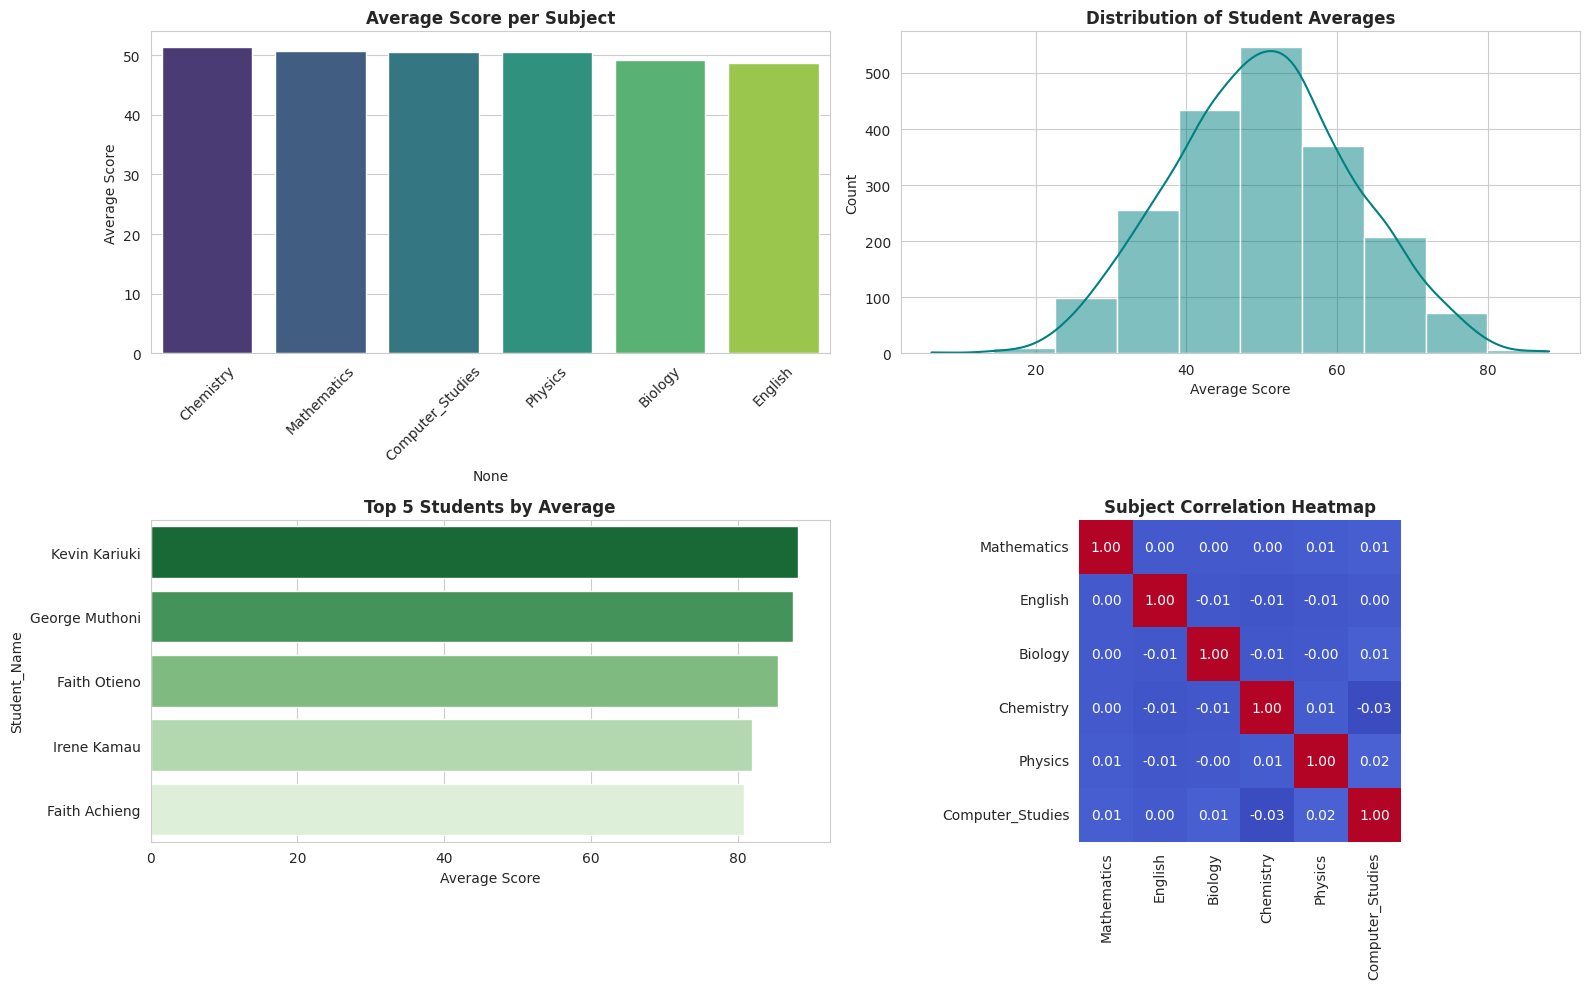

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
subject_cols = ['Mathematics', 'English', 'Biology', 'Chemistry', 'Physics', 'Computer_Studies']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Chart 1: Bar chart of average score per subject
subject_means = df[subject_cols].mean().sort_values(ascending=False)
sns.barplot(x=subject_means.index, y=subject_means.values, ax=axes[0, 0],
            hue=subject_means.index, palette='viridis', legend=False)
axes[0, 0].set_title('Average Score per Subject', fontweight='bold')
axes[0, 0].set_ylabel('Average Score')
axes[0, 0].tick_params(axis='x', rotation=45)

# Chart 2: Distribution of Averages
sns.histplot(df['Average'], bins=10, kde=True, ax=axes[0, 1], color='teal')
axes[0, 1].set_title('Distribution of Student Averages', fontweight='bold')
axes[0, 1].set_xlabel('Average Score')

# Chart 3: Top 5 students
top5 = df.nlargest(5, 'Average')
sns.barplot(x='Average', y='Student_Name', data=top5, ax=axes[1, 0],
            hue='Student_Name', palette='Greens_r', legend=False)
axes[1, 0].set_title('Top 5 Students by Average', fontweight='bold')
axes[1, 0].set_xlabel('Average Score')

# Chart 4: Correlation Heatmap
sns.heatmap(df[subject_cols].corr(), annot=True, cmap='coolwarm',
            fmt='.2f', ax=axes[1, 1], square=True, cbar=False)
axes[1, 1].set_title('Subject Correlation Heatmap', fontweight='bold')

plt.tight_layout()
plt.show()

In [39]:
# Add a rank column
df['Rank'] = df['Average'].rank(ascending=True, method='min').astype(int)

# Add a Grade column based on average
def assign_grade(avg):
    if avg >= 70: return 'A'
    elif avg >= 60: return 'B'
    elif avg >= 50: return 'C'
    elif avg >= 40: return 'D'
    else: return 'E'

df['Grade'] = df['Average'].apply(assign_grade)

# Quick check to confirm it worked
print(df[['Student_Name', 'Average', 'Grade']].head())

     Student_Name  Average Grade
0    Oscar Otieno    67.83     B
1   Queen Onyango    53.17     C
2    Irene Wambui    49.33     D
3  Caroline Maina    55.50     C
4    Kevin Chebet    41.83     D


creating Grade column and testing if it has applied

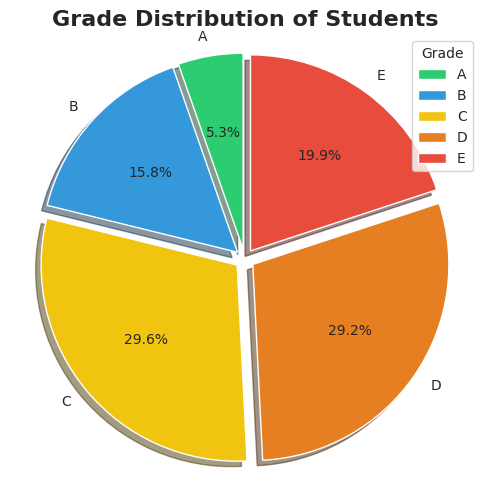

In [41]:
import matplotlib.pyplot as plt

# Count how many students got each grade
grade_counts = df['Grade'].value_counts().sort_index()

# Define colors for each grade
colors = ['#2ecc71', '#3498db', '#f1c40f', '#e67e22', '#e74c3c']
colors = colors[:len(grade_counts)]

plt.figure(figsize=(5, 5))

plt.pie(grade_counts.values,
        labels=grade_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        explode=[0.05] * len(grade_counts),
        shadow=True)

plt.title('Grade Distribution of Students', fontsize=16, fontweight='bold')
plt.legend(title='Grade', loc='upper right')
plt.axis('equal')

plt.tight_layout()
plt.show()